# Cancer Detection: Feature Selection & Correlation Analysis

This notebook identifies the most important features for cancer detection using Pearson correlation.

**Process:**
1. Drop highly correlated features (redundant information)
2. Rank remaining features by their correlation with the diagnosis label
3. Visualize why features matter

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

path="../../results/reports/biggest_component_features_Whales.csv"

df = pd.read_csv(path)


X = df[['melanoma_color_count','hue_variance',
 'saturation_variance','value_variance','mabrouk_asymmetry_score',
 'avg_asymmetry_score','worst_score','Polsby-Popper','convexity_score',
 'lesion_red_share','lesion_green_share','lesion_blue_share',
 'lesion_skin_red_diff','lesion_skin_green_diff','lesion_skin_blue_diff',
 'lesion_skin_rgb_distance']]
y = df["skin_cancer_diagnosis"]


# Smaller df grouped by patiend_id
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

# Splits by patiend id and stratify by patients using .max() to check if patient have a cancerous lesion. 
# First split: train vs test+val
train_patients, testval_patients = train_test_split(
    patients,
    test_size=0.4,
    random_state=42,
    stratify=labels
)

# Second split: test vs val, still by patient_id
testval_labels = patient_labels.loc[testval_patients]

test_patients, val_patients = train_test_split(
    testval_patients,
    test_size=0.5,
    random_state=42,
    stratify=testval_labels
)

train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)
val_mask = df["patient_id"].isin(val_patients)

X_train = X[train_mask]
X_test = X[test_mask]
X_val = X[val_mask]

y_train = y[train_mask]
y_test = y[test_mask]
y_val = y[val_mask]

threshold = 0.8
max_allowed = 3
corr = X_train.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1
to_drop = counts[counts > max_allowed].index.tolist()
X_reduced = X_train.drop(columns=to_drop)

# rank by absolute correlation with label and pick top 10
label_col = "Skin_cancer_diagnosis"
df_rank = X_reduced.copy()
df_rank[label_col] = y_train
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10 = corr_with_label.sort_values(ascending=False).head(10).index.tolist()

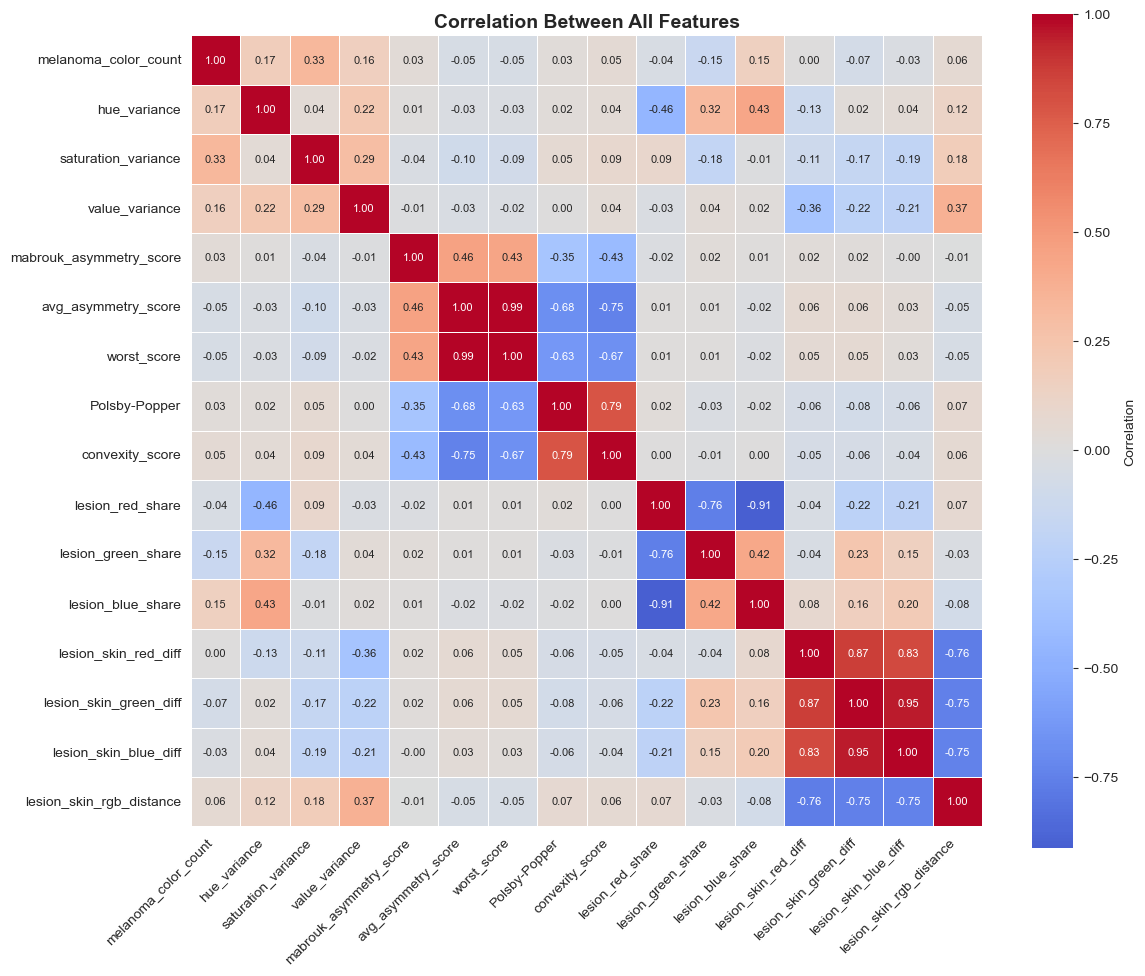

Features are correlated if they have similar information.
Features with >0.8 correlation will be dropped if too many are grouped together.



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

fig, ax = plt.subplots(figsize=(12, 10))

# Compute correlation matrix
corr_matrix = X_train.corr()

# Plot heatmap with values in each square
sns.heatmap(
    corr_matrix,
    annot=True,               
    fmt=".2f",               
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,          
    cbar_kws={"label": "Correlation"},
    annot_kws={"size": 8}, 
    ax=ax
)

# Rotate axis labels for readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

ax.set_title(
    "Correlation Between All Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("Features are correlated if they have similar information.")
print("Features with >0.8 correlation will be dropped if too many are grouped together.\n")

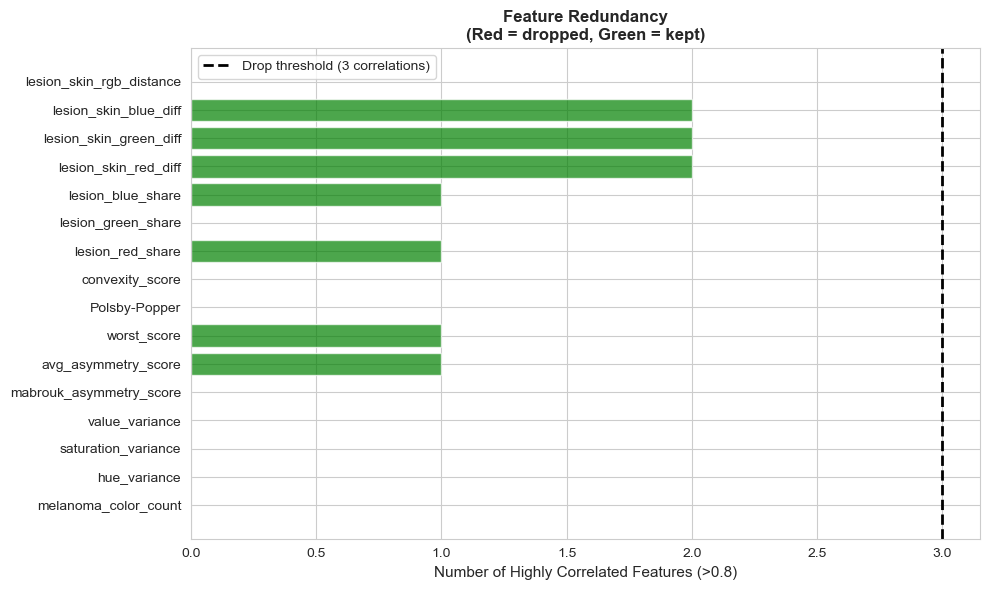

In [3]:

# Show which features have too many correlations
fig, ax = plt.subplots(figsize=(10, 6))
corr = X_train.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1

# Separate dropped vs kept
dropped_features = counts[counts > max_allowed].index.tolist()
kept_features = [f for f in counts.index if f not in dropped_features]

colors = ["red" if f in dropped_features else "green" for f in counts.index]
bars = ax.barh(range(len(counts)), counts.values, color=colors, alpha=0.7)

ax.set_yticks(range(len(counts)))
ax.set_yticklabels(counts.index)
ax.axvline(x=max_allowed, color="black", linestyle="--", linewidth=2, 
           label=f"Drop threshold ({max_allowed} correlations)")
ax.set_xlabel("Number of Highly Correlated Features (>0.8)", fontsize=11)
ax.set_title(f"Feature Redundancy\n(Red = dropped, Green = kept)", 
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

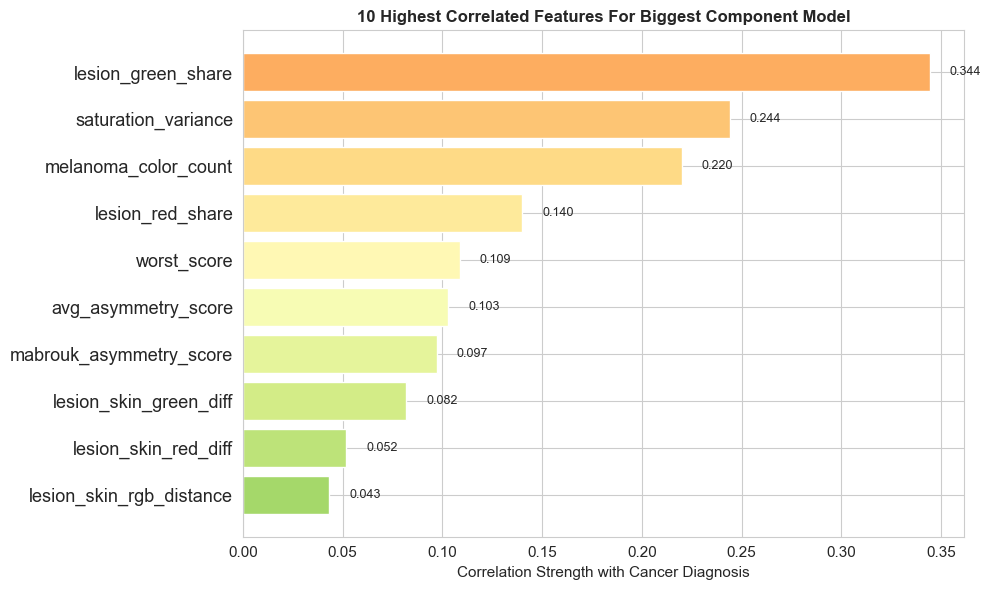

In [8]:
# Calculate correlation with target
df_rank = X_train[top10].copy()
df_rank[label_col] = y
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10_features = corr_with_label.sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top10_features)))
bars = ax.barh(range(len(top10_features)), top10_features.values, color=colors_gradient)


ax.set_yticks(range(len(top10_features)))
ax.set_yticklabels(top10_features.index)

ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel("Correlation Strength with Cancer Diagnosis", fontsize=11)
ax.set_title("10 Highest Correlated Features For Biggest Component Model", 
             fontsize=12, fontweight="bold")
ax.invert_yaxis()

# Add value labels on bars
for i, (feat, val) in enumerate(top10_features.items()):
    ax.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
top10_features.index

Index(['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper'],
      dtype='object')